## GM Regime Classification And Trend-Following Backtest

This notebook imports General Motors stock history from Yahoo Finance, classifies its historical regime with a walk-forward Gaussian HMM, and compares:

- Buy and hold GM.
- Long-only HMM timing: buy when the model classifies GM as an uptrend and move to cash when it classifies GM as a downtrend.

The notebook also keeps the Kalman trend baseline from the original workflow so you can visualize how price and HMM states interact over time.

### Step 1. Load GM price history and set model parameters
This cell imports the project code, pulls GM price history, and defines the parameters used by the Kalman filter, feature scaling, and walk-forward HMM.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

cwd = Path.cwd().resolve()
project_root = next(path for path in (cwd, *cwd.parents) if (path / "src" / "finance").exists())
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from finance.data.ingestion import load_symbol_history


def format_history_label(period: str) -> str:
    unit_names = {"d": "day", "mo": "month", "y": "year"}
    for unit, unit_name in unit_names.items():
        if period.endswith(unit):
            value = period[: -len(unit)]
            if value.isdigit():
                suffix = "" if value == "1" else "s"
                return f"{value}-{unit_name}{suffix} history"
    return f"{period} history"


symbol = "GM"
history_period = "20y"
history_label = format_history_label(history_period)
vol_window = 21
expanding_scaler_min_periods = 63
n_states = 2
hmm_train_min_periods = 252
hmm_refit_frequency = 21
kalman_process_variance = 0.01
kalman_measurement_variance = 25.0
kalman_burn_in_periods = 252
initial_capital_usd = 1000.0

gm_rows = load_symbol_history(symbol, period=history_period)
strategy_data = pd.DataFrame(gm_rows)
if strategy_data.empty:
    raise RuntimeError("No GM price history was returned from yfinance.")

strategy_data["date"] = pd.to_datetime(strategy_data["Date"], utc=True)
strategy_data = strategy_data.rename(
    columns={
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Volume": "volume",
    }
)
strategy_data = strategy_data.sort_values("date").reset_index(drop=True)

strategy_data[["date", "open", "high", "low", "close", "volume"]].tail()

,date,open,high,low,close,volume
3871,2026-04-14 04:00:00+00:00,78.629997,79.860001,78.099998,79.459999,5859600
3872,2026-04-15 04:00:00+00:00,79.540001,79.540001,77.760002,77.779999,6475600
3873,2026-04-16 04:00:00+00:00,77.589996,78.349998,77.010002,78.050003,5615100
3874,2026-04-17 04:00:00+00:00,79.400002,82.669998,79.400002,81.320000,7295300
3875,2026-04-20 04:00:00+00:00,80.860001,81.160004,80.324997,80.360001,1926051


### Step 2. Engineer raw price, volatility, and volume features
The HMM will eventually use standardized features, but first this cell creates the raw daily return, rolling volatility, and volume-change inputs that the rest of the workflow builds on.

In [2]:
strategy_data["observed_close"] = strategy_data["close"].astype(float)
strategy_data["log_close"] = np.log(strategy_data["observed_close"])
strategy_data["log_return_1d"] = strategy_data["log_close"].diff()
strategy_data["realized_vol_21d"] = (
    strategy_data["log_return_1d"].rolling(vol_window).std() * np.sqrt(252)
)
strategy_data["volume_change_1d"] = np.log1p(strategy_data["volume"]).diff()

model_data = strategy_data.dropna(subset=["log_return_1d", "realized_vol_21d", "volume_change_1d"]).reset_index(drop=True)

model_data[["date", "observed_close", "log_return_1d", "realized_vol_21d", "volume_change_1d"]].tail()

,date,observed_close,log_return_1d,realized_vol_21d,volume_change_1d
3850,2026-04-14 04:00:00+00:00,79.459999,0.033659,0.340479,0.389265
3851,2026-04-15 04:00:00+00:00,77.779999,-0.021369,0.351675,0.099960
3852,2026-04-16 04:00:00+00:00,78.050003,0.003465,0.349073,-0.142582
3853,2026-04-17 04:00:00+00:00,81.320000,0.041042,0.371563,0.261771
3854,2026-04-20 04:00:00+00:00,80.360001,-0.011875,0.376030,-1.331758


### Step 3. Build the Kalman trend reference and standardized HMM inputs
This cell smooths GM into a Kalman trend, derives trend-aware features, and then standardizes every HMM input with prior-only expanding statistics so the model uses only information that would have existed at the time.

In [3]:
def run_kalman_filter(
    series: pd.Series,
    process_variance: float,
    measurement_variance: float,
    initial_state_covariance: float = 1.0,
) -> tuple[list[float], list[float]]:
    state_estimate = float(series.iloc[0])
    state_covariance = initial_state_covariance
    filtered_close = []
    kalman_gain = []

    for observed_value in series:
        predicted_estimate = state_estimate
        predicted_covariance = state_covariance + process_variance
        innovation = observed_value - predicted_estimate
        innovation_variance = predicted_covariance + measurement_variance
        gain = predicted_covariance / innovation_variance

        state_estimate = predicted_estimate + gain * innovation
        state_covariance = (1.0 - gain) * predicted_covariance
        filtered_close.append(state_estimate)
        kalman_gain.append(gain)

    return filtered_close, kalman_gain


def expanding_standardize_by_feature(
    frame: pd.DataFrame,
    columns: list[str],
    min_periods: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    prior_feature_means = (
        frame[columns]
        .expanding(min_periods=min_periods)
        .mean()
        .shift(1)
    )
    prior_feature_stds = (
        frame[columns]
        .expanding(min_periods=min_periods)
        .std(ddof=0)
        .shift(1)
        .replace(0.0, np.nan)
    )
    standardized = frame[columns].sub(prior_feature_means).div(prior_feature_stds)
    return standardized, prior_feature_means, prior_feature_stds


filtered_close, kalman_gain = run_kalman_filter(
    model_data["observed_close"],
    process_variance=kalman_process_variance,
    measurement_variance=kalman_measurement_variance,
    initial_state_covariance=1.0,
)

model_data["kalman_close"] = filtered_close
model_data["noise"] = model_data["observed_close"] - model_data["kalman_close"]
model_data["rolling_noise_std"] = (
    model_data["noise"]
    .expanding(min_periods=vol_window)
    .std(ddof=0)
    .shift(1)
    .bfill()
    .replace(0.0, np.nan)
    .fillna(1.0)
)
model_data["distance_to_trend_z"] = model_data["noise"] / model_data["rolling_noise_std"]
model_data["kalman_trend_return_5d"] = np.log(model_data["kalman_close"]).diff(5)

feature_columns = [
    "log_return_1d",
    "realized_vol_21d",
    "volume_change_1d",
    "distance_to_trend_z",
    "kalman_trend_return_5d",
]
observation_columns = [f"{column}_z" for column in feature_columns]

model_data = model_data.dropna(subset=feature_columns).reset_index(drop=True)

standardized_features, feature_means, feature_stds = expanding_standardize_by_feature(
    model_data,
    feature_columns,
    min_periods=expanding_scaler_min_periods,
)
valid_rows = standardized_features.notna().all(axis=1)
model_data = model_data.loc[valid_rows].reset_index(drop=True)
feature_means = feature_means.loc[valid_rows].reset_index(drop=True)
feature_stds = feature_stds.loc[valid_rows].reset_index(drop=True)
standardized_features = standardized_features.loc[valid_rows].reset_index(drop=True).astype(float)
model_data[observation_columns] = standardized_features.to_numpy()
hmm_observations = model_data[observation_columns].to_numpy(dtype=float)

if not np.isfinite(hmm_observations).all():
    raise ValueError("Scaled HMM observations must be finite after per-feature standardization.")

if kalman_burn_in_periods >= len(model_data):
    raise ValueError("kalman_burn_in_periods must be smaller than the number of model observations.")

model_data = model_data.iloc[kalman_burn_in_periods:].reset_index(drop=True)
hmm_observations = hmm_observations[kalman_burn_in_periods:]

scaling_audit = pd.DataFrame(
    {
        "raw_feature_std": model_data[feature_columns].std(ddof=0).round(4),
        "scaled_feature_std": model_data[observation_columns].std(ddof=0).round(4).to_numpy(),
        "scaled_feature_mean": model_data[observation_columns].mean().round(4).to_numpy(),
    },
    index=feature_columns,
)

scaling_audit

,raw_feature_std,scaled_feature_std,scaled_feature_mean
log_return_1d,0.0214,1.0549,0.0150
realized_vol_21d,0.1380,1.1423,0.0321
volume_change_1d,0.3971,0.9374,-0.0016
distance_to_trend_z,1.2986,1.1215,0.1878
kalman_trend_return_5d,0.0098,1.0832,0.1716


### Step 4. Run a walk-forward HMM and label states as bull or bear
Each HMM refit uses only historical data available at that date. The hidden states are mapped to bull-trend and bear-trend using the Kalman trend return first and raw return second, which keeps the labels tied to trend direction instead of pure volatility.

In [4]:
def label_states_by_trend(profile: pd.DataFrame) -> dict[int, str]:
    ordered_states = profile.sort_values(["mean_trend_return", "mean_return"]).index.to_list()
    if len(ordered_states) != 2:
        raise ValueError("This notebook expects a 2-state HMM.")
    bear_state = int(ordered_states[0])
    bull_state = int(ordered_states[-1])
    return {bear_state: "bear-trend", bull_state: "bull-trend"}


walk_forward_hidden_state = np.full(len(model_data), np.nan)
walk_forward_regime_label = np.full(len(model_data), "", dtype=object)
refit_points: list[str] = []
last_fitted_model: GaussianHMM | None = None
last_state_labels: dict[int, str] = {}

for train_end in range(hmm_train_min_periods, len(model_data), hmm_refit_frequency):
    train_observations = hmm_observations[:train_end]
    hmm_model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=500,
        random_state=42,
        min_covar=1e-4,
    )
    hmm_model.fit(train_observations)

    train_states = hmm_model.predict(train_observations)
    train_frame = model_data.iloc[:train_end].copy()
    train_frame["hidden_state"] = train_states

    train_profile = train_frame.groupby("hidden_state").agg(
        mean_return=("log_return_1d", "mean"),
        mean_trend_return=("kalman_trend_return_5d", "mean"),
        mean_volatility=("realized_vol_21d", "mean"),
        mean_distance_to_trend=("distance_to_trend_z", "mean"),
        count=("hidden_state", "size"),
    )
    if len(train_profile) != n_states:
        continue

    state_labels = label_states_by_trend(train_profile)

    block_end = min(train_end + hmm_refit_frequency, len(model_data))
    for prediction_end in range(train_end + 1, block_end + 1):
        prefix_states = hmm_model.predict(hmm_observations[:prediction_end])
        predicted_state = int(prefix_states[-1])
        walk_forward_hidden_state[prediction_end - 1] = predicted_state
        walk_forward_regime_label[prediction_end - 1] = state_labels[predicted_state]

    last_fitted_model = hmm_model
    last_state_labels = state_labels
    refit_points.append(model_data.iloc[train_end - 1]["date"].date().isoformat())

predicted_hidden_state = walk_forward_hidden_state[hmm_train_min_periods:]
predicted_regime_label = walk_forward_regime_label[hmm_train_min_periods:]
if np.isnan(predicted_hidden_state).any() or any(label == "" for label in predicted_regime_label):
    raise RuntimeError("Walk-forward HMM did not assign a state to every post-training observation.")

model_data = model_data.iloc[hmm_train_min_periods:].reset_index(drop=True)
model_data["hidden_state"] = predicted_hidden_state.astype(int)
model_data["regime_label"] = predicted_regime_label
hmm_observations = hmm_observations[hmm_train_min_periods:]
hmm_model = last_fitted_model
state_labels = last_state_labels

state_profile = model_data.groupby("regime_label").agg(
    mean_return=("log_return_1d", "mean"),
    mean_trend_return=("kalman_trend_return_5d", "mean"),
    mean_volatility=("realized_vol_21d", "mean"),
    mean_distance_to_trend=("distance_to_trend_z", "mean"),
    count=("regime_label", "size"),
).assign(
    share_of_sample=lambda frame: frame["count"] / frame["count"].sum()
).round(4)

state_profile

,mean_return,mean_trend_return,mean_volatility,mean_distance_to_trend,count,share_of_sample
regime_label,,,,,,
bear-trend,-0.0000,-0.0017,0.2461,-0.2275,1502,0.4575
bull-trend,0.0006,0.0043,0.3674,0.5969,1781,0.5425


### Step 5. Visualize GM price, Kalman trend, and HMM regime
Bull periods are shown in green and bear periods in red.

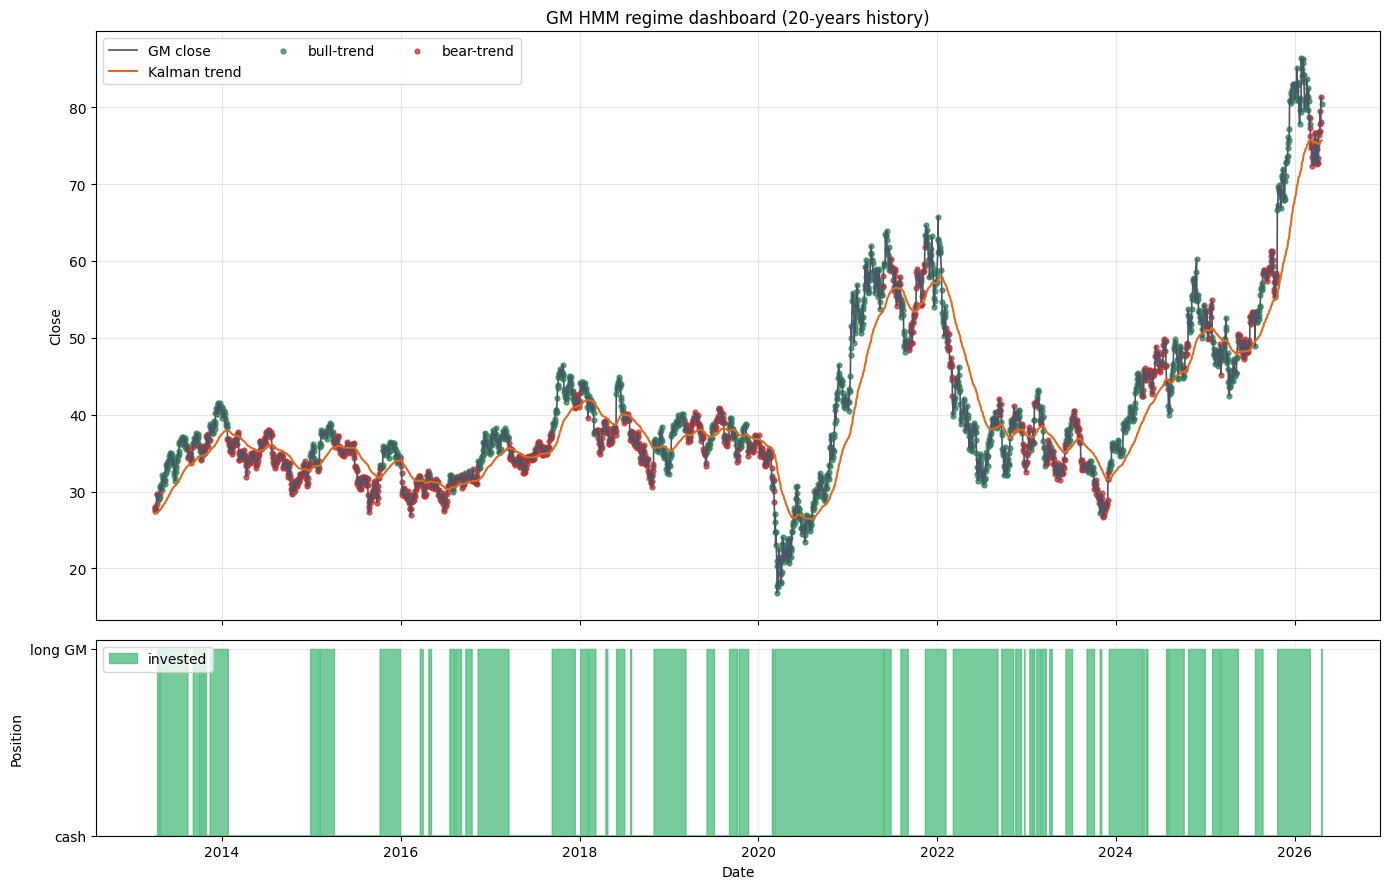

In [5]:
plot_data = model_data.copy()
plot_data["invested_indicator"] = (plot_data["regime_label"] == "bull-trend").astype(int)
regime_colors = {"bull-trend": "#2f855a", "bear-trend": "#c53030"}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(
    plot_data["date"],
    plot_data["observed_close"],
    color="#4a5568",
    linewidth=1.2,
    label=f"{symbol} close",
)
axes[0].plot(
    plot_data["date"],
    plot_data["kalman_close"],
    color="#dd6b20",
    linewidth=1.5,
    label="Kalman trend",
)

for regime_label, color in regime_colors.items():
    regime_mask = plot_data["regime_label"] == regime_label
    if regime_mask.any():
        axes[0].scatter(
            plot_data.loc[regime_mask, "date"],
            plot_data.loc[regime_mask, "observed_close"],
            s=12,
            alpha=0.75,
            color=color,
            label=regime_label,
        )

axes[0].set_title(f"{symbol} HMM regime dashboard ({history_label})")
axes[0].set_ylabel("Close")
axes[0].grid(alpha=0.3)
axes[0].legend(ncol=3)

axes[1].fill_between(
    plot_data["date"],
    0,
    plot_data["invested_indicator"],
    step="mid",
    color="#48bb78",
    alpha=0.75,
    label="invested",
)
axes[1].set_ylim(0, 1.05)
axes[1].set_yticks([0, 1], labels=["cash", "long GM"])
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Position")
axes[1].grid(alpha=0.2)
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

### Step 6. Backtest buy-and-hold versus the HMM timing rule
The HMM strategy is long GM only when the prior session was labeled bull-trend. When the prior session was bear-trend, it sits in cash with a 0 percent return assumption.

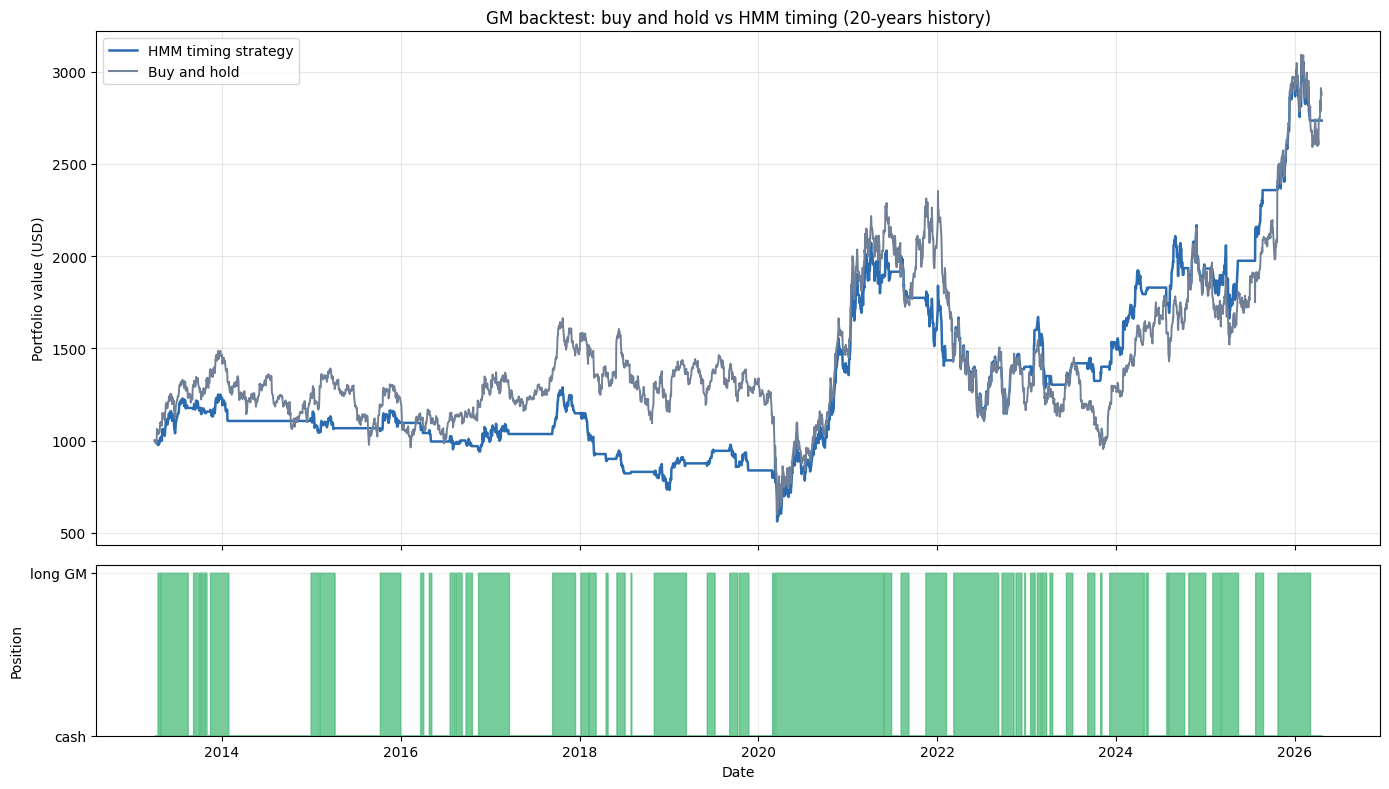

{
  "symbol": "GM",
  "currency": "USD",
  "initial_capital": 1000.0,
  "sample_start": "2013-04-02",
  "sample_end": "2026-04-20",
  "assumptions": {
    "execution_timing": "Signal observed after the close, position applied on the next trading day.",
    "risk_off_asset": "Cash",
    "cash_return_assumption": 0.0,
    "transaction_costs_included": false
  },
  "strategy": {
    "rule": "Long GM when the prior session is labeled bull-trend; otherwise hold cash.",
    "final_value_usd": 2735.4,
    "total_return": 1.7354,
    "cagr": 0.0803,
    "max_drawdown": -0.5639,
    "invested_days": 1780,
    "cash_days": 1503,
    "turnover_events": 116
  },
  "buy_and_hold": {
    "final_value_usd": 2877.19,
    "total_return": 1.8772,
    "cagr": 0.0845,
    "max_drawdown": -0.6386
  }
}


In [6]:
backtest_data = model_data[[
    "date",
    "observed_close",
    "regime_label",
    "distance_to_trend_z",
]].copy()
backtest_data["asset_return"] = backtest_data["observed_close"].pct_change().fillna(0.0)
backtest_data["bull_signal"] = backtest_data["regime_label"].eq("bull-trend")

# Trade on the next session to avoid using same-day information.
backtest_data["position"] = np.where(
    backtest_data["bull_signal"].shift(1, fill_value=False),
    1.0,
    0.0,
)
backtest_data["strategy_return"] = backtest_data["position"] * backtest_data["asset_return"]
backtest_data["buy_and_hold_return"] = backtest_data["asset_return"]

backtest_data["strategy_value_usd"] = initial_capital_usd * (1.0 + backtest_data["strategy_return"]).cumprod()
backtest_data["buy_and_hold_value_usd"] = initial_capital_usd * (1.0 + backtest_data["buy_and_hold_return"]).cumprod()
backtest_data["strategy_drawdown"] = (
    backtest_data["strategy_value_usd"]
    / backtest_data["strategy_value_usd"].cummax()
    - 1.0
)
backtest_data["buy_and_hold_drawdown"] = (
    backtest_data["buy_and_hold_value_usd"]
    / backtest_data["buy_and_hold_value_usd"].cummax()
    - 1.0
)

trading_days = max(len(backtest_data), 1)
strategy_total_return = backtest_data["strategy_value_usd"].iloc[-1] / initial_capital_usd - 1.0
buy_and_hold_total_return = backtest_data["buy_and_hold_value_usd"].iloc[-1] / initial_capital_usd - 1.0
strategy_cagr = (backtest_data["strategy_value_usd"].iloc[-1] / initial_capital_usd) ** (252 / trading_days) - 1.0
buy_and_hold_cagr = (backtest_data["buy_and_hold_value_usd"].iloc[-1] / initial_capital_usd) ** (252 / trading_days) - 1.0
strategy_max_drawdown = float(backtest_data["strategy_drawdown"].min())
buy_and_hold_max_drawdown = float(backtest_data["buy_and_hold_drawdown"].min())
invested_days = int(backtest_data["position"].sum())
cash_days = int((backtest_data["position"] == 0.0).sum())
turnover_events = int(backtest_data["position"].diff().abs().fillna(0.0).sum())

backtest_summary = {
    "symbol": symbol,
    "currency": "USD",
    "initial_capital": round(initial_capital_usd, 2),
    "sample_start": backtest_data["date"].min().date().isoformat(),
    "sample_end": backtest_data["date"].max().date().isoformat(),
    "assumptions": {
        "execution_timing": "Signal observed after the close, position applied on the next trading day.",
        "risk_off_asset": "Cash",
        "cash_return_assumption": 0.0,
        "transaction_costs_included": False,
    },
    "strategy": {
        "rule": "Long GM when the prior session is labeled bull-trend; otherwise hold cash.",
        "final_value_usd": round(float(backtest_data["strategy_value_usd"].iloc[-1]), 2),
        "total_return": round(float(strategy_total_return), 4),
        "cagr": round(float(strategy_cagr), 4),
        "max_drawdown": round(strategy_max_drawdown, 4),
        "invested_days": invested_days,
        "cash_days": cash_days,
        "turnover_events": turnover_events,
    },
    "buy_and_hold": {
        "final_value_usd": round(float(backtest_data["buy_and_hold_value_usd"].iloc[-1]), 2),
        "total_return": round(float(buy_and_hold_total_return), 4),
        "cagr": round(float(buy_and_hold_cagr), 4),
        "max_drawdown": round(float(buy_and_hold_max_drawdown), 4),
    },
}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(
    backtest_data["date"],
    backtest_data["strategy_value_usd"],
    color="#2b6cb0",
    linewidth=1.8,
    label="HMM timing strategy",
)
axes[0].plot(
    backtest_data["date"],
    backtest_data["buy_and_hold_value_usd"],
    color="#718096",
    linewidth=1.4,
    label="Buy and hold",
)
axes[0].set_title(f"GM backtest: buy and hold vs HMM timing ({history_label})")
axes[0].set_ylabel("Portfolio value (USD)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].fill_between(
    backtest_data["date"],
    0,
    backtest_data["position"],
    step="mid",
    color="#48bb78",
    alpha=0.75,
)
axes[1].set_ylim(0, 1.05)
axes[1].set_yticks([0, 1], labels=["cash", "long GM"])
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Position")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(json.dumps(backtest_summary, indent=2))

### Step 7. Export a compact regime summary
This gives you the latest GM regime classification together with the most recent backtest summary.

In [7]:
latest = model_data.iloc[-1]
prior = model_data.iloc[-2]
last_five_sessions = model_data.tail(5)

regime_summary = {
    "symbol": symbol,
    "history_period": history_period,
    "sample_start": model_data["date"].min().date().isoformat(),
    "sample_end": model_data["date"].max().date().isoformat(),
    "latest_observation": {
        "date": latest["date"].date().isoformat(),
        "close": round(float(latest["observed_close"]), 2),
        "kalman_trend": round(float(latest["kalman_close"]), 2),
        "distance_to_trend_z": round(float(latest["distance_to_trend_z"]), 4),
        "hidden_state": int(latest["hidden_state"]),
        "regime_label": latest["regime_label"],
        "regime_changed_today": bool(latest["regime_label"] != prior["regime_label"]),
    },
    "state_profile": [
        {
            "regime_label": regime_label,
            "observations": int(row["count"]),
            "share_of_sample": round(float(row["share_of_sample"]), 4),
            "mean_log_return_1d": round(float(row["mean_return"]), 6),
            "mean_realized_vol_21d": round(float(row["mean_volatility"]), 6),
            "mean_distance_to_trend_z": round(float(row["mean_distance_to_trend"]), 6),
        }
        for regime_label, row in state_profile.iterrows()
    ],
    "recent_sessions": [
        {
            "date": row.date().isoformat(),
            "regime_label": label,
        }
        for row, label in zip(last_five_sessions["date"], last_five_sessions["regime_label"], strict=True)
    ],
    "walk_forward_configuration": {
        "train_min_periods": hmm_train_min_periods,
        "refit_frequency": hmm_refit_frequency,
        "recent_refit_dates": refit_points[-5:],
    },
    "backtest_summary": backtest_summary,
}

print(json.dumps(regime_summary, indent=2))

{
  "symbol": "GM",
  "history_period": "20y",
  "sample_start": "2013-04-02",
  "sample_end": "2026-04-20",
  "latest_observation": {
    "date": "2026-04-20",
    "close": 80.36,
    "kalman_trend": 75.69,
    "distance_to_trend_z": 1.1709,
    "hidden_state": 1,
    "regime_label": "bull-trend",
    "regime_changed_today": true
  },
  "state_profile": [
    {
      "regime_label": "bear-trend",
      "observations": 1502,
      "share_of_sample": 0.4575,
      "mean_log_return_1d": -0.0,
      "mean_realized_vol_21d": 0.2461,
      "mean_distance_to_trend_z": -0.2275
    },
    {
      "regime_label": "bull-trend",
      "observations": 1781,
      "share_of_sample": 0.5425,
      "mean_log_return_1d": 0.0006,
      "mean_realized_vol_21d": 0.3674,
      "mean_distance_to_trend_z": 0.5969
    }
  ],
  "recent_sessions": [
    {
      "date": "2026-04-14",
      "regime_label": "bear-trend"
    },
    {
      "date": "2026-04-15",
      "regime_label": "bear-trend"
    },
    {
     